# Assignment: Knowledge Distillation for Sentiment Classification

## Introduction

**Knowledge Distillation (KD)** is a model compression technique in which a smaller model, called the **student**, learns from a larger model, called the **teacher**.

The goal is to transfer useful knowledge from the teacher to the student so that the student can achieve competitive performance while requiring fewer computational resources.

In this assignment, we will investigate two knowledge distillation approaches:

- **Response-based distillation:** The student learns from the teacher's output predictions, such as class probabilities.

- **Feature-based distillation:** The student learns from the teacher's intermediate representations, such as hidden-layer features.

**Learning Objectives**

By the end of this assignment, you should be able to:
- Explain the teacher–student learning framework and the motivation behind knowledge distillation.
- Understand the difference between response-based and feature-based knowledge distillation.
- Train a student model with and without knowledge distillation.
- Analyze whether transferring knowledge from the teacher improves the student's performance.

---

## 1. Environment Setup

In this section, we will prepare the Python environment for implementing knowledge distillation.

We will use the following libraries:

- **PyTorch:** For building and training neural networks.
- **Transformers:** For loading pretrained teacher and student models.
- **Datasets:** For downloading and preparing the SST-2 dataset.
- **Scikit-learn:** For data splitting and model evaluation.
- **NumPy:** For numerical operations.
- **Matplotlib:** For visualizing training results.

### 1.1. Install Required Packages

The required package versions are installed to ensure a consistent and reproducible environment.

In [122]:
# ============================================================
# DEPENDENCY CHECK
# ============================================================

import sys
import subprocess
import importlib.util

# Package name -> required version
# None means any installed version is acceptable
required_packages = {
    "numpy": None,
    "pandas": None,
    "matplotlib": None,
    "scikit-learn": None,
    "torch": None,
    "wordcloud": None,
    "datasets": "4.8.5",
    "transformers": "4.57.0",
    "huggingface_hub": "0.35.3",
}

# Import names that differ from pip package names
import_names = {
    "scikit-learn": "sklearn",
    "huggingface_hub": "huggingface_hub",
}

# Install only missing packages
for package, version in required_packages.items():
    import_name = import_names.get(package, package)

    if importlib.util.find_spec(import_name) is None:
        install_name = f"{package}=={version}" if version else package

        print(f"Installing missing package: {install_name}")

        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            install_name
        ])
    else:
        print(f"{package}: already installed")

print("\nDependency check completed.")

numpy: already installed
pandas: already installed
matplotlib: already installed
scikit-learn: already installed
torch: already installed
wordcloud: already installed
datasets: already installed
transformers: already installed
huggingface_hub: already installed

Dependency check completed.


### 1.2. Imports and Configuration

All required libraries are imported in one place. 

In [ ]:
# ============================================================
# IMPORTS AND CONFIGURATION
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torch.optim import AdamW

from datasets import load_dataset, DatasetDict

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

from wordcloud import WordCloud


# Device configuration
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Device:", device)
print("Environment setup completed successfully!")

PyTorch version: 2.14.0+cpu
Device: cpu
Environment setup completed successfully!


---

## 2. Dataset and Task Description

### 2.1. Task: Sentiment Classification

In this assignment, we will work on a **binary sentiment classification** task. Given a movie review, the model must predict whether the expressed sentiment is positive or negative.

**Example 1:**

- Input: "The movie was fantastic, and I really enjoyed the acting."
- Expected output: **Positive (1)**

**Example 2:**

- Input: "The movie was boring and disappointing."
- Expected output: **Negative (0)**

The model will predict two class probabilities: the probability that the review is negative and the probability that it is positive.

### 2.2. Dataset: Stanford Sentiment Treebank (SST-2)

We will use the **Stanford Sentiment Treebank (SST-2)**, a publicly available dataset containing movie-review sentences annotated with binary sentiment labels.

**Dataset source:** [SST-2 on Hugging Face](https://huggingface.co/datasets/stanfordnlp/sst2)

Each example contains a sentence and its corresponding sentiment label:

- **0:** Negative sentiment
- **1:** Positive sentiment

The original dataset contains **67,349 training examples** and **872 validation examples**.

To make the assignment manageable on computers without dedicated GPUs, we will use a smaller subset of the labeled training data:

| Split | Number of Examples | Purpose |
|---|---:|---|
| Training | 2,000 | Train the student models |
| Validation | 400 | Monitor training and select model configurations |
| Test | 400 | Evaluate the final models on unseen examples |

We will create three non-overlapping subsets using a fixed random seed and stratified sampling to preserve the class distribution.

The official SST-2 validation split will remain untouched. All models will use the same dataset splits to ensure a consistent experimental comparison.

### 2.3. Dataset Preparation

##### 2.3.1. Loading the Original Dataset

In [157]:
# Load the original SST-2 dataset
dataset = load_dataset("stanfordnlp/sst2")

# Display dataset information
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 872
    })
    test: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 1821
    })
})


In [158]:
# Display the first five training examples

for i in range(5):
    example = dataset["train"][i]

    print(f"Example {i + 1}")
    print("Sentence:", example["sentence"])
    print("Label:", example["label"])
    print("-" * 60)

Example 1
Sentence: hide new secretions from the parental units 
Label: 0
------------------------------------------------------------
Example 2
Sentence: contains no wit , only labored gags 
Label: 0
------------------------------------------------------------
Example 3
Sentence: that loves its characters and communicates something rather beautiful about human nature 
Label: 1
------------------------------------------------------------
Example 4
Sentence: remains utterly satisfied to remain the same throughout 
Label: 0
------------------------------------------------------------
Example 5
Sentence: on the worst revenge-of-the-nerds clichés the filmmakers could dredge up 
Label: 0
------------------------------------------------------------


In [159]:
# Convert the original training dataset to a DataFrame
df = dataset["train"].to_pandas()

# Randomly select five positive and five negative reviews
positive_reviews = df[df["label"] == 1].sample(
    n=5, random_state=42
)

negative_reviews = df[df["label"] == 0].sample(
    n=5, random_state=42
)

# Combine the selected reviews
examples = pd.concat(
    [positive_reviews, negative_reviews]
)

# Add readable sentiment labels
examples["Sentiment"] = examples["label"].map({
    0: "Negative",
    1: "Positive"
})

# Display the examples
display(
    examples[["sentence", "Sentiment"]]
    .rename(columns={"sentence": "Movie Review"})
    .reset_index(drop=True)
)

,Movie Review,Sentiment
0,acted meditation on both the profoundly devast...,Positive
1,"this odd , poetic road movie , spiked by jolts...",Positive
2,directed with purpose and finesse by england '...,Positive
3,long and eventful,Positive
4,the best of the pierce brosnan james bond film...,Positive
5,"a dull , dumb and derivative horror",Negative
6,"if george romero had directed this movie , it ...",Negative
7,"the acting is amateurish , the cinematography ...",Negative
8,maudlin ending,Negative
9,derailed,Negative


### 2.4 Dataset Exploration and Visualization

Before training the teacher and student models, we will explore the prepared SST-2 dataset to better understand its characteristics.

We will examine the following:

1. **Sentiment Label Distribution:** Visualize the number of positive and negative reviews to examine class balance.
2. **Sentence Length Distribution:** Analyze the lengths of movie reviews to understand the input data.
3. **Example Reviews:** Explore positive and negative reviews to better understand the sentiment classification task.

These observations will help us understand the dataset before proceeding to model training and knowledge distillation.

#### Sentiment Label Distribution

We will visualize the number of positive and negative reviews in the training dataset to examine whether the two sentiment classes are balanced.

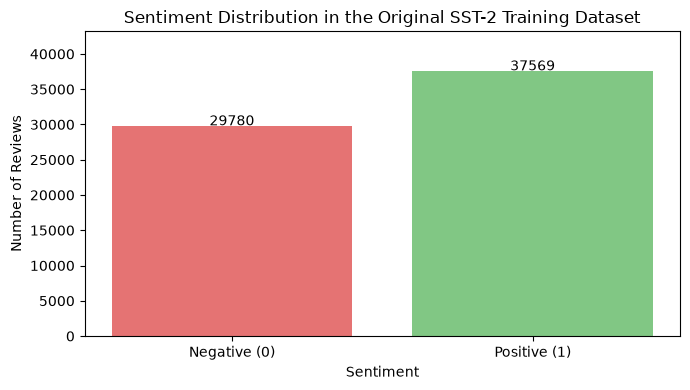

In [160]:
# Get sentiment labels from the original training dataset
labels = np.array(dataset["train"]["label"])

# Count negative and positive reviews
negative_count = np.sum(labels == 0)
positive_count = np.sum(labels == 1)

# Create a bar chart
plt.figure(figsize=(7, 4))

plt.bar(
    ["Negative (0)", "Positive (1)"],
    [negative_count, positive_count],
    color=["#E57373", "#81C784"]
)

plt.title("Sentiment Distribution in the Original SST-2 Training Dataset")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

# Display the exact number above each bar
for i, count in enumerate([negative_count, positive_count]):
    plt.text(i, count + 100, str(count), ha="center")

plt.ylim(0, max(negative_count, positive_count) * 1.15)
plt.tight_layout()
plt.show()

Number of reviews: 67349
Minimum length: 1 words
Maximum length: 52 words
Average length: 9.41 words
Median length: 7.0 words
95th percentile: 26.0 words


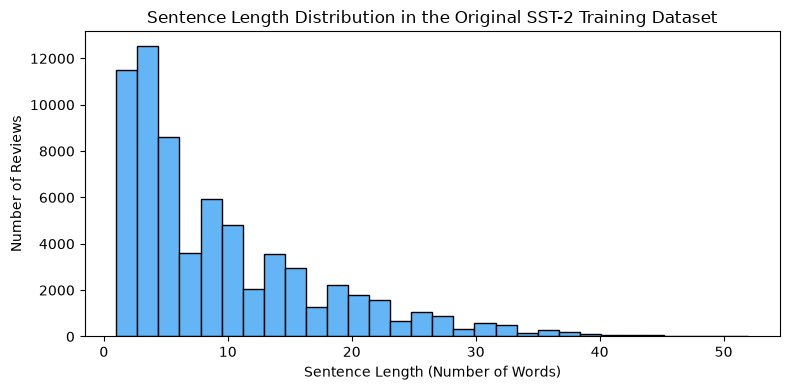

In [161]:
# Calculate the number of words in each review
sentence_lengths = [
    len(sentence.split())
    for sentence in dataset["train"]["sentence"]
]

# Display sentence length statistics
print("Number of reviews:", len(sentence_lengths))
print("Minimum length:", min(sentence_lengths), "words")
print("Maximum length:", max(sentence_lengths), "words")
print("Average length:", round(np.mean(sentence_lengths), 2), "words")
print("Median length:", np.median(sentence_lengths), "words")
print("95th percentile:", np.percentile(sentence_lengths, 95), "words")

# Visualize sentence length distribution
plt.figure(figsize=(8, 4))

plt.hist(
    sentence_lengths,
    bins=30,
    color="#64B5F6",
    edgecolor="black"
)

plt.title("Sentence Length Distribution in the Original SST-2 Training Dataset")
plt.xlabel("Sentence Length (Number of Words)")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

##### Sentiment Word Visualization

Word clouds provide a visual overview of frequently occurring words in the SST-2 dataset. Separate word clouds are generated for negative and positive sentences to illustrate differences in vocabulary across the two sentiment classes.

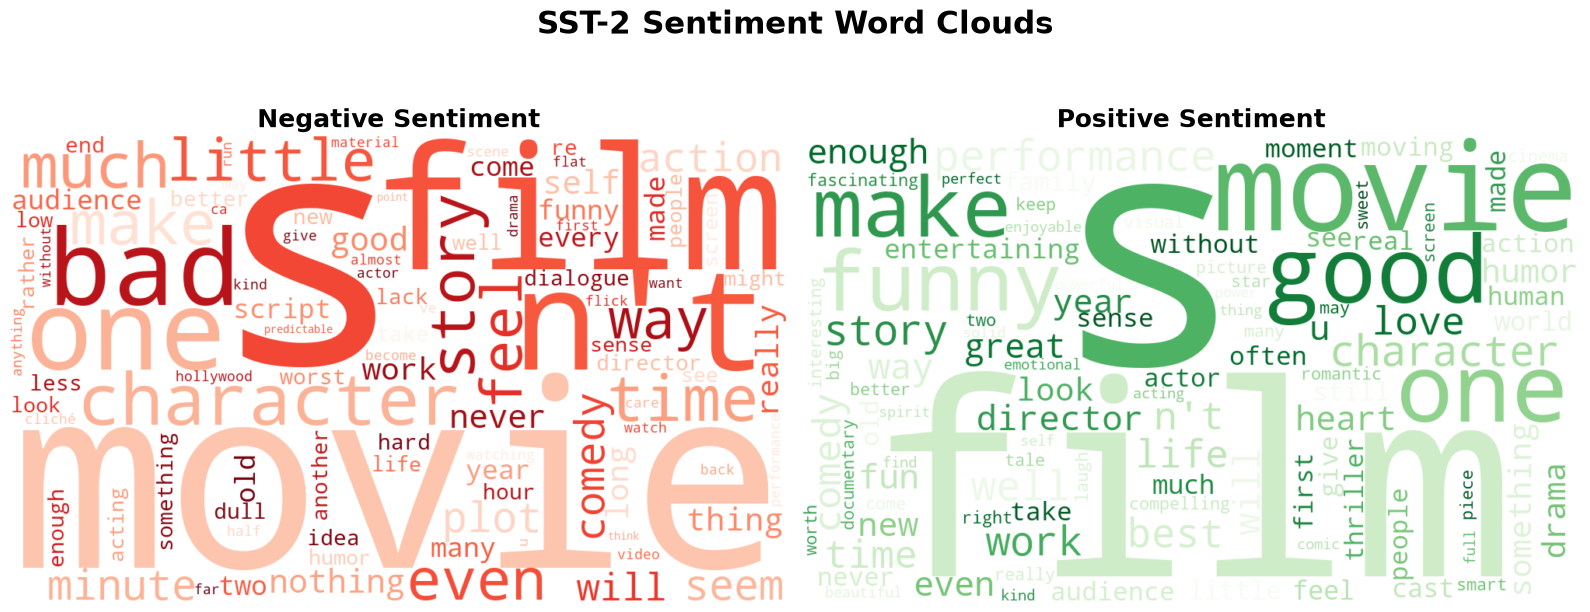

In [162]:
# Separate training sentences by sentiment
negative_text = " ".join(
    example["sentence"]
    for example in dataset["train"]
    if example["label"] == 0
)

positive_text = " ".join(
    example["sentence"]
    for example in dataset["train"]
    if example["label"] == 1
)

# Generate word clouds
negative_cloud = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    colormap="Reds",
    max_words=100,
    collocations=False,
    random_state=42
).generate(negative_text)

positive_cloud = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    colormap="Greens",
    max_words=100,
    collocations=False,
    random_state=42
).generate(positive_text)

# Visualize side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(negative_cloud, interpolation="bilinear")
axes[0].set_title(
    "Negative Sentiment",
    fontsize=18,
    fontweight="bold"
)
axes[0].axis("off")

axes[1].imshow(positive_cloud, interpolation="bilinear")
axes[1].set_title(
    "Positive Sentiment",
    fontsize=18,
    fontweight="bold"
)
axes[1].axis("off")

fig.suptitle(
    "SST-2 Sentiment Word Clouds",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

---

## 3. Data Preparation for Training

In [131]:
# Select 2,800 examples from the original training dataset
train_indices, _ = train_test_split(
    range(len(dataset["train"])),
    train_size=2800,
    stratify=dataset["train"]["label"],
    random_state=42
)

selected_data = dataset["train"].select(train_indices)

# Split into training (2,000) and temporary (800) subsets
train_indices, temp_indices = train_test_split(
    range(len(selected_data)),
    train_size=2000,
    stratify=selected_data["label"],
    random_state=42
)

# Split the temporary subset into validation (400) and test (400)
temp_data = selected_data.select(temp_indices)

val_indices, test_indices = train_test_split(
    range(len(temp_data)),
    test_size=400,
    stratify=temp_data["label"],
    random_state=42
)

# Create the final dataset
dataset_small = DatasetDict({
    "train": selected_data.select(train_indices),
    "validation": temp_data.select(val_indices),
    "test": temp_data.select(test_indices)
})

# Display the final dataset structure
print(dataset_small)

DatasetDict({
    train: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 2000
    })
    validation: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 400
    })
    test: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 400
    })
})


##### Saving the Prepared Dataset

The final stratified dataset splits are saved locally in the `data/processed/` folder for reproducibility and later use.

The prepared dataset contains:

- **Training:** 2,000 examples
- **Validation:** 400 examples
- **Test:** 400 examples

In [132]:
# Create folders for the prepared dataset
DATA_DIR = Path("data")
PROCESSED_DIR = DATA_DIR / "processed"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Save each prepared split
for split in ["train", "validation", "test"]:
    file_path = PROCESSED_DIR / f"{split}.csv"

    dataset_small[split].to_csv(
        file_path,
        index=False
    )

    print(f"Saved: {file_path.resolve()}")

Creating CSV from Arrow format: 100%|██████████| 2/2 [00:00<00:00, 92.63ba/s]


Saved: C:\Users\User\Desktop\EDGE FL - Summer School\2. Lab\2. EAI\data\processed\train.csv


Creating CSV from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 219.72ba/s]


Saved: C:\Users\User\Desktop\EDGE FL - Summer School\2. Lab\2. EAI\data\processed\validation.csv


Creating CSV from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 158.47ba/s]

Saved: C:\Users\User\Desktop\EDGE FL - Summer School\2. Lab\2. EAI\data\processed\test.csv


## 4. Teacher and Student Models

Two pretrained Transformer models will be used in this assignment.

### Teacher Model

The teacher model is **DistilBERT fine-tuned on SST-2**:

`distilbert-base-uncased-finetuned-sst-2-english`

- Approximately **66 million parameters**
- **6 Transformer layers**
- Already fine-tuned for binary sentiment classification
- Used to provide knowledge to the smaller student model

### Student Model

The student model is **BERT-Tiny**:

`prajjwal1/bert-tiny`

- Approximately **4.4 million parameters**
- **2 Transformer layers**
- Much smaller and faster than the teacher
- Its classification head will be trained for the sentiment classification task

The goal is to transfer knowledge from the larger teacher model to the smaller student model while maintaining good classification performance.

##### 4.1. Loading the Teacher and Student Models

In [133]:
# Create local model folders
TEACHER_DIR = Path("models/teacher")
STUDENT_DIR = Path("models/student")

TEACHER_DIR.mkdir(parents=True, exist_ok=True)
STUDENT_DIR.mkdir(parents=True, exist_ok=True)

# Hugging Face model names
teacher_model_name = "distilbert-base-uncased-finetuned-sst-2-english"
student_model_name = "prajjwal1/bert-tiny"

# Download teacher
teacher_tokenizer = AutoTokenizer.from_pretrained(teacher_model_name)
teacher_model = AutoModelForSequenceClassification.from_pretrained(
    teacher_model_name
)

teacher_tokenizer.save_pretrained(TEACHER_DIR)
teacher_model.save_pretrained(TEACHER_DIR)

# Download student
student_tokenizer = AutoTokenizer.from_pretrained(student_model_name)
student_model = AutoModelForSequenceClassification.from_pretrained(
    student_model_name,
    num_labels=2
)

student_tokenizer.save_pretrained(STUDENT_DIR)
student_model.save_pretrained(STUDENT_DIR)

print("Teacher saved to:", TEACHER_DIR.resolve())
print("Student saved to:", STUDENT_DIR.resolve())

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Teacher saved to: C:\Users\User\Desktop\EDGE FL - Summer School\2. Lab\2. EAI\models\teacher
Student saved to: C:\Users\User\Desktop\EDGE FL - Summer School\2. Lab\2. EAI\models\student


Verifying the Teacher and Student Models

 - Before training, we verify that both models were loaded correctly and compare their sizes by counting the number of parameters.

In [134]:
# Count the number of parameters in each model
teacher_params = sum(p.numel() for p in teacher_model.parameters())
student_params = sum(p.numel() for p in student_model.parameters())

print(f"Teacher parameters: {teacher_params:,}")
print(f"Student parameters: {student_params:,}")
print(f"Student is {teacher_params / student_params:.1f}x smaller than the teacher.")

Teacher parameters: 66,955,010
Student parameters: 4,386,178
Student is 15.3x smaller than the teacher.


##### 4.3. Testing the Teacher Model

Before using the teacher for knowledge distillation, we test it on a sample sentence to verify that it produces sentiment predictions correctly.

In [135]:
# Example sentence
sample_text = "This movie was absolutely wonderful and enjoyable."

# Tokenize the sentence
inputs = teacher_tokenizer(
    sample_text,
    return_tensors="pt"
)

# Make a prediction
teacher_model.eval()

with torch.no_grad():
    outputs = teacher_model(**inputs)

# Get the predicted class
predicted_class = torch.argmax(outputs.logits, dim=1).item()

label_names = {
    0: "Negative",
    1: "Positive"
}

print("Sentence:", sample_text)
print("Prediction:", label_names[predicted_class])

Sentence: This movie was absolutely wonderful and enjoyable.
Prediction: Positive


##### 4.4. Teacher Baseline Evaluation

The teacher model is evaluated on the prepared SST-2 test set to establish a reference baseline. Its performance will later be compared with the normally trained student and the students trained using response-based and feature-based knowledge distillation.

In [ ]:
# Tokenize the test set using the teacher tokenizer
def tokenize_teacher(batch):
    return teacher_tokenizer(
        batch["sentence"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

teacher_test = dataset_small["test"].map(
    tokenize_teacher,
    batched=True
)

teacher_test.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

teacher_test_loader = DataLoader(
    teacher_test,
    batch_size=32
)

# Evaluate the teacher
teacher_model.to(device)
teacher_model.eval()

teacher_predictions = []
teacher_labels = []

with torch.no_grad():
    for batch in teacher_test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = teacher_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = torch.argmax(outputs.logits, dim=1)

        teacher_predictions.extend(predictions.cpu().numpy())
        teacher_labels.extend(labels.cpu().numpy())

# Calculate evaluation metrics
teacher_accuracy = accuracy_score(
    teacher_labels,
    teacher_predictions
)

teacher_f1 = f1_score(
    teacher_labels,
    teacher_predictions
)

print(f"Teacher Accuracy: {teacher_accuracy:.4f}")
print(f"Teacher F1 Score: {teacher_f1:.4f}")

Map: 100%|██████████| 400/400 [00:00<00:00, 3881.49 examples/s]


Teacher Accuracy: 0.9900
Teacher F1 Score: 0.9910


##### 4.5. Student Baseline

The student model is first trained using standard supervised learning with the ground-truth SST-2 labels, without knowledge distillation. This provides a baseline for evaluating whether response-based and feature-based knowledge distillation improve the student model.

In [137]:
# Tokenize the datasets using the student tokenizer
def tokenize_student(batch):
    return student_tokenizer(
        batch["sentence"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

student_train = dataset_small["train"].map(
    tokenize_student,
    batched=True
)

student_validation = dataset_small["validation"].map(
    tokenize_student,
    batched=True
)

student_test = dataset_small["test"].map(
    tokenize_student,
    batched=True
)

print("Training examples:", len(student_train))
print("Validation examples:", len(student_validation))
print("Test examples:", len(student_test))

Map: 100%|██████████| 400/400 [00:00<00:00, 5143.91 examples/s]

Training examples: 2000
Validation examples: 400
Test examples: 400


In [138]:
# Convert datasets to PyTorch format
for split in [student_train, student_validation, student_test]:
    split.set_format(
        type="torch",
        columns=["input_ids", "attention_mask", "label"]
    )

# Create DataLoaders
student_train_loader = DataLoader(
    student_train,
    batch_size=32,
    shuffle=True
)

student_validation_loader = DataLoader(
    student_validation,
    batch_size=32
)

student_test_loader = DataLoader(
    student_test,
    batch_size=32
)

print("Training batches:", len(student_train_loader))
print("Validation batches:", len(student_validation_loader))
print("Test batches:", len(student_test_loader))

Training batches: 63
Validation batches: 13
Test batches: 13


In [163]:
# Move the student model to the selected device
student_model.to(device)

# Training settings
learning_rate = 2e-5
num_epochs = 5

# Optimizer
optimizer = AdamW(
    student_model.parameters(),
    lr=learning_rate
)

print("Device:", device)
print("Learning rate:", learning_rate)
print("Number of epochs:", num_epochs)

Device: cpu
Learning rate: 2e-05
Number of epochs: 5


In [164]:
# Train the student baseline using ground-truth labels only

for epoch in range(num_epochs):

    student_model.train()
    total_loss = 0

    for batch in student_train_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = student_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss

        # Backpropagation
        loss.backward()

        # Update model parameters
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(student_train_loader)

    print(
        f"Epoch {epoch + 1}/{num_epochs} - "
        f"Training Loss: {average_loss:.4f}"
    )

Epoch 1/5 - Training Loss: 0.6524
Epoch 2/5 - Training Loss: 0.6343
Epoch 3/5 - Training Loss: 0.6101
Epoch 4/5 - Training Loss: 0.5784
Epoch 5/5 - Training Loss: 0.5448


In [165]:
# Evaluate the baseline student on the test set

student_model.eval()

baseline_predictions = []
baseline_labels = []

with torch.no_grad():
    for batch in student_test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = student_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = torch.argmax(outputs.logits, dim=1)

        baseline_predictions.extend(predictions.cpu().numpy())
        baseline_labels.extend(labels.cpu().numpy())

# Calculate evaluation metrics
baseline_accuracy = accuracy_score(
    baseline_labels,
    baseline_predictions
)

baseline_f1 = f1_score(
    baseline_labels,
    baseline_predictions
)

print(f"Student Baseline Accuracy: {baseline_accuracy:.4f}")
print(f"Student Baseline F1 Score: {baseline_f1:.4f}")

Student Baseline Accuracy: 0.7250
Student Baseline F1 Score: 0.7577


In [166]:
# Save the trained baseline student model

BASELINE_DIR = Path("models/student_baseline")
BASELINE_DIR.mkdir(parents=True, exist_ok=True)

student_model.save_pretrained(BASELINE_DIR)
student_tokenizer.save_pretrained(BASELINE_DIR)

print("Baseline student saved to:", BASELINE_DIR.resolve())

Baseline student saved to: C:\Users\User\Desktop\EDGE FL - Summer School\2. Lab\2. EAI\models\student_baseline


---

## 5. Knowledge Distillation

We will investigate two knowledge distillation approaches.

##### 5.1. Response-Based Distillation

The student learns from the teacher's output probabilities.

Example: "The movie was interesting, but the ending was disappointing."

Teacher predictions:
- Negative: 70%

- Positive: 30%

Instead of learning only from the original label, the student also learns to match the teacher's probability distribution.

In [167]:
# Response-based knowledge distillation settings
temperature = 2.0
alpha = 0.5

print("Temperature:", temperature)
print("Alpha:", alpha)

Temperature: 2.0
Alpha: 0.5


In [168]:
# Initialize the response-KD student from the supervised baseline

response_student = AutoModelForSequenceClassification.from_pretrained(
    "models/student_baseline"
)

response_student.to(device)

response_optimizer = AdamW(
    response_student.parameters(),
    lr=2e-5
)

print("Response-KD student initialized from supervised baseline.")
print(
    "Parameters:",
    f"{sum(p.numel() for p in response_student.parameters()):,}"
)

Response-KD student initialized from supervised baseline.
Parameters: 4,386,178


In [169]:
# Train Response-KD v2 from the supervised baseline

teacher_model.eval()

for epoch in range(num_epochs):

    response_student.train()
    total_loss = 0

    for batch in student_train_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        response_optimizer.zero_grad()

        # Teacher predictions
        with torch.no_grad():
            teacher_outputs = teacher_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

        # Student predictions
        student_outputs = response_student(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Ground-truth classification loss
        hard_loss = F.cross_entropy(
            student_outputs.logits,
            labels
        )

        # Teacher-student distillation loss
        soft_loss = F.kl_div(
            F.log_softmax(
                student_outputs.logits / temperature,
                dim=1
            ),
            F.softmax(
                teacher_outputs.logits / temperature,
                dim=1
            ),
            reduction="batchmean"
        ) * (temperature ** 2)

        # Combined loss
        loss = (
            alpha * hard_loss
            + (1 - alpha) * soft_loss
        )

        loss.backward()
        response_optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(student_train_loader)

    print(
        f"Epoch {epoch + 1}/{num_epochs} - "
        f"KD Loss: {average_loss:.4f}"
    )

Epoch 1/5 - KD Loss: 1.1854
Epoch 2/5 - KD Loss: 1.1137
Epoch 3/5 - KD Loss: 1.0504
Epoch 4/5 - KD Loss: 0.9801
Epoch 5/5 - KD Loss: 0.9176


In [170]:
# Evaluate the response-KD student on the validation set

response_student.eval()

response_val_predictions = []
response_val_labels = []

with torch.no_grad():
    for batch in student_validation_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = response_student(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = torch.argmax(outputs.logits, dim=1)

        response_val_predictions.extend(predictions.cpu().numpy())
        response_val_labels.extend(labels.cpu().numpy())

response_val_accuracy = accuracy_score(
    response_val_labels,
    response_val_predictions
)

response_val_f1 = f1_score(
    response_val_labels,
    response_val_predictions
)

print(f"Response-KD Validation Accuracy: {response_val_accuracy:.4f}")
print(f"Response-KD Validation F1 Score: {response_val_f1:.4f}")

Response-KD Validation Accuracy: 0.7625
Response-KD Validation F1 Score: 0.7865


In [171]:
# Evaluate the response-KD student on the test set

response_student.eval()

response_test_predictions = []
response_test_labels = []

with torch.no_grad():
    for batch in student_test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = response_student(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = torch.argmax(outputs.logits, dim=1)

        response_test_predictions.extend(predictions.cpu().numpy())
        response_test_labels.extend(labels.cpu().numpy())

response_accuracy = accuracy_score(
    response_test_labels,
    response_test_predictions
)

response_f1 = f1_score(
    response_test_labels,
    response_test_predictions
)

print(f"Student Baseline Test Accuracy: {baseline_accuracy:.4f}")
print(f"Student Baseline Test F1:       {baseline_f1:.4f}")
print()
print(f"Response-KD Test Accuracy:      {response_accuracy:.4f}")
print(f"Response-KD Test F1:            {response_f1:.4f}")

Student Baseline Test Accuracy: 0.7250
Student Baseline Test F1:       0.7577

Response-KD Test Accuracy:      0.7600
Response-KD Test F1:            0.7714


In [172]:
# Save the response-KD student

RESPONSE_KD_DIR = Path("models/student_response_kd")
RESPONSE_KD_DIR.mkdir(parents=True, exist_ok=True)

response_student.save_pretrained(RESPONSE_KD_DIR)
student_tokenizer.save_pretrained(RESPONSE_KD_DIR)

print("Response-KD student saved to:", RESPONSE_KD_DIR.resolve())

Response-KD student saved to: C:\Users\User\Desktop\EDGE FL - Summer School\2. Lab\2. EAI\models\student_response_kd


##### 5.2. Feature-Based Distillation

The student learns from the teacher's intermediate hidden-layer representations.

- Teacher hidden dimension: 768

- Student hidden dimension: 128

Since their dimensions differ, a trainable linear projection maps the student's representations from 128 to 768 dimensions.

The student learns to minimize the difference between its projected representations and the teacher's representations.

In [173]:
# Initialize feature-KD student from the supervised baseline

feature_student = AutoModelForSequenceClassification.from_pretrained(
    "models/student_baseline"
)

feature_student.to(device)

# Projection for Student layer 1 -> Teacher layer 3
projection_layer1 = nn.Linear(
    feature_student.config.hidden_size,
    teacher_model.config.hidden_size
).to(device)

# Projection for Student layer 2 -> Teacher layer 6
projection_layer2 = nn.Linear(
    feature_student.config.hidden_size,
    teacher_model.config.hidden_size
).to(device)

print("Student hidden size:", feature_student.config.hidden_size)
print("Teacher hidden size:", teacher_model.config.hidden_size)
print("Feature-KD student initialized from supervised baseline.")
print()
print("Layer mapping:")
print("Student layer 1 -> Teacher layer 3")
print("Student layer 2 -> Teacher layer 6")

Student hidden size: 128
Teacher hidden size: 768
Feature-KD student initialized from supervised baseline.

Layer mapping:
Student layer 1 -> Teacher layer 3
Student layer 2 -> Teacher layer 6


In [174]:
# Feature-based KD training settings

feature_alpha = 0.5

feature_optimizer = AdamW(
    list(feature_student.parameters()) +
    list(projection_layer1.parameters()) +
    list(projection_layer2.parameters()),
    lr=2e-5
)

print("Feature loss weight:", feature_alpha)
print("Learning rate:", 2e-5)
print("Number of epochs:", num_epochs)

Feature loss weight: 0.5
Learning rate: 2e-05
Number of epochs: 5


In [175]:
# Train using intermediate-layer feature-based knowledge distillation

teacher_model.eval()

for epoch in range(num_epochs):

    feature_student.train()
    projection_layer1.train()
    projection_layer2.train()

    total_loss = 0

    for batch in student_train_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        feature_optimizer.zero_grad()

        # Get teacher hidden states
        with torch.no_grad():
            teacher_outputs = teacher_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_hidden_states=True
            )

        # Get student hidden states
        student_outputs = feature_student(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True
        )

        # Normal supervised classification loss
        hard_loss = F.cross_entropy(
            student_outputs.logits,
            labels
        )

        # Student layer 1 -> Teacher layer 3
        student_layer1 = student_outputs.hidden_states[1][:, 0, :]
        teacher_layer3 = teacher_outputs.hidden_states[3][:, 0, :]

        projected_layer1 = projection_layer1(student_layer1)

        loss_layer1 = F.mse_loss(
            projected_layer1,
            teacher_layer3
        )

        # Student layer 2 -> Teacher layer 6
        student_layer2 = student_outputs.hidden_states[2][:, 0, :]
        teacher_layer6 = teacher_outputs.hidden_states[6][:, 0, :]

        projected_layer2 = projection_layer2(student_layer2)

        loss_layer2 = F.mse_loss(
            projected_layer2,
            teacher_layer6
        )

        # Average feature-matching loss
        feature_loss = (loss_layer1 + loss_layer2) / 2

        # Combine supervised and feature losses
        loss = (
            feature_alpha * hard_loss
            + (1 - feature_alpha) * feature_loss
        )

        loss.backward()
        feature_optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(student_train_loader)

    print(
        f"Epoch {epoch + 1}/{num_epochs} - "
        f"Feature-KD Loss: {average_loss:.4f}"
    )

Epoch 1/5 - Feature-KD Loss: 0.5886
Epoch 2/5 - Feature-KD Loss: 0.5390
Epoch 3/5 - Feature-KD Loss: 0.4953
Epoch 4/5 - Feature-KD Loss: 0.4520
Epoch 5/5 - Feature-KD Loss: 0.4142


In [176]:
# Evaluate Feature-KD student on the validation set

feature_student.eval()

feature_val_predictions = []
feature_val_labels = []

with torch.no_grad():
    for batch in student_validation_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = feature_student(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = torch.argmax(outputs.logits, dim=1)

        feature_val_predictions.extend(predictions.cpu().numpy())
        feature_val_labels.extend(labels.cpu().numpy())

feature_val_accuracy = accuracy_score(
    feature_val_labels,
    feature_val_predictions
)

feature_val_f1 = f1_score(
    feature_val_labels,
    feature_val_predictions
)

print(f"Feature-KD Validation Accuracy: {feature_val_accuracy:.4f}")
print(f"Feature-KD Validation F1 Score: {feature_val_f1:.4f}")

Feature-KD Validation Accuracy: 0.7475
Feature-KD Validation F1 Score: 0.7809


In [177]:
# Evaluate Feature-KD student on the test set

feature_student.eval()

feature_test_predictions = []
feature_test_labels = []

with torch.no_grad():
    for batch in student_test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = feature_student(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = torch.argmax(outputs.logits, dim=1)

        feature_test_predictions.extend(predictions.cpu().numpy())
        feature_test_labels.extend(labels.cpu().numpy())

feature_accuracy = accuracy_score(
    feature_test_labels,
    feature_test_predictions
)

feature_f1 = f1_score(
    feature_test_labels,
    feature_test_predictions
)

print(f"Student Baseline Test Accuracy: {baseline_accuracy:.4f}")
print(f"Student Baseline Test F1:       {baseline_f1:.4f}")
print()
print(f"Feature-KD Test Accuracy:       {feature_accuracy:.4f}")
print(f"Feature-KD Test F1:             {feature_f1:.4f}")

Student Baseline Test Accuracy: 0.7250
Student Baseline Test F1:       0.7577

Feature-KD Test Accuracy:       0.7825
Feature-KD Test F1:             0.8027


In [178]:
# Save the Feature-KD student

FEATURE_KD_DIR = Path("models/student_feature_kd")
FEATURE_KD_DIR.mkdir(parents=True, exist_ok=True)

# Save student model and tokenizer
feature_student.save_pretrained(FEATURE_KD_DIR)
student_tokenizer.save_pretrained(FEATURE_KD_DIR)

# Save intermediate-layer projection modules
torch.save(
    projection_layer1.state_dict(),
    FEATURE_KD_DIR / "projection_layer1.pt"
)

torch.save(
    projection_layer2.state_dict(),
    FEATURE_KD_DIR / "projection_layer2.pt"
)

print("Feature-KD student saved to:", FEATURE_KD_DIR.resolve())

Feature-KD student saved to: C:\Users\User\Desktop\EDGE FL - Summer School\2. Lab\2. EAI\models\student_feature_kd


##### 5.3. Final Comparison

We will compare the following models:

1. Teacher model
2. Student baseline
3. Response-based distilled student
4. Feature-based distilled student

The models will be compared using classification accuracy, F1 score, and model size.

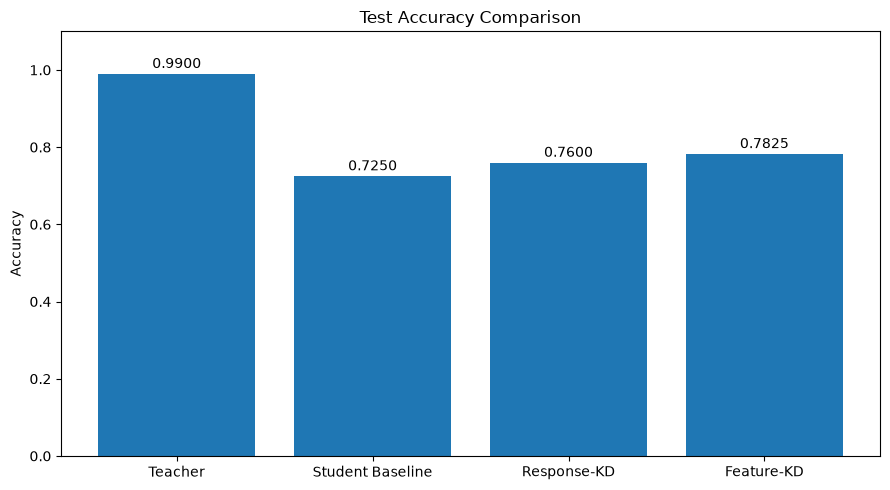

In [179]:
models = [
    "Teacher",
    "Student Baseline",
    "Response-KD",
    "Feature-KD"
]

accuracies = [
    teacher_accuracy,
    baseline_accuracy,
    response_accuracy,
    feature_accuracy
]

plt.figure(figsize=(9, 5))

bars = plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("Test Accuracy Comparison")
plt.ylim(0, 1.1)

for bar, value in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.015,
        f"{value:.4f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

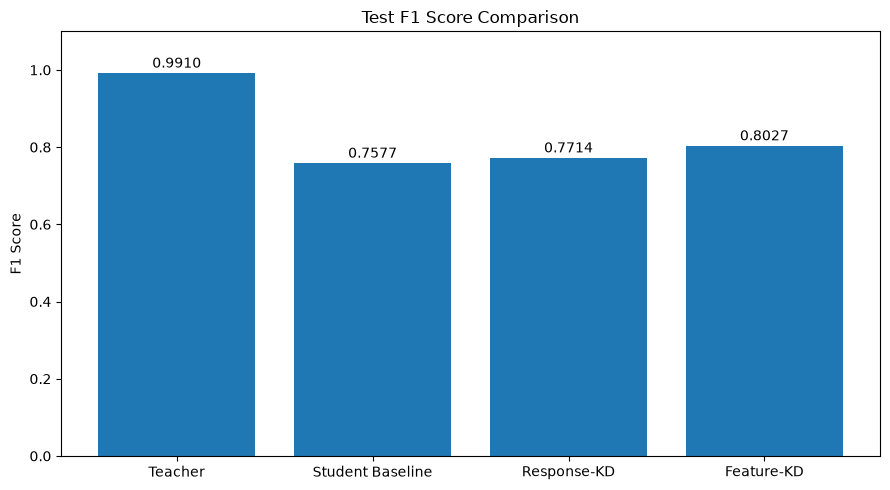

In [180]:
f1_scores = [
    teacher_f1,
    baseline_f1,
    response_f1,
    feature_f1
]

plt.figure(figsize=(9, 5))

bars = plt.bar(models, f1_scores)

plt.ylabel("F1 Score")
plt.title("Test F1 Score Comparison")
plt.ylim(0, 1.1)

for bar, value in zip(bars, f1_scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.015,
        f"{value:.4f}",
        ha="center"
    )

plt.tight_layout()
plt.show()